# Exploring EmFit Value Added Catalog

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fitsio

In [3]:
columns_to_read = [
    "TARGETID", 
    "TARGET_RA",
    "TARGET_DEC",
    "Z",
    "HB_N_FLUX",
    "HB_N_FLUX_ERR",
    "OIII5007_FLUX",
    "OIII5007_FLUX_ERR",
    "HA_N_FLUX",
    "HA_N_FLUX_ERR",
    "NII6583_FLUX",
    "NII6583_FLUX_ERR",
    ]

emfit_fname = "~/Downloads/emfit-dr1-v2.3.1.fits"
data = fitsio.read(emfit_fname, ext=1, columns=columns_to_read)

# The following is necessary to avoid and endianness problem
emfit = pd.DataFrame({
    col: np.asarray(data[col], dtype=data[col].dtype.newbyteorder('<'))
    for col in data.dtype.names
})

In [4]:
selection = emfit.query("NII6583_FLUX / NII6583_FLUX_ERR > 3 "
                        "and Z < 0.15 "
                        "and OIII5007_FLUX > 0 "
                        "and HA_N_FLUX > 0 "
                        "and TARGET_DEC < 10")

In [5]:
selection[['NII6583_FLUX', 'OIII5007_FLUX', 'HB_N_FLUX', 'HA_N_FLUX']].describe()

,NII6583_FLUX,OIII5007_FLUX,HB_N_FLUX,HA_N_FLUX
count,535048.000000,5.350480e+05,535048.000000,5.350480e+05
mean,37.036042,4.776601e+01,29.773210,7.445999e+03
std,90.066076,2.293865e+02,62.219777,3.470192e+06
min,0.000909,3.774483e-07,0.000000,7.978556e-04
25%,8.031305,7.766289e+00,8.013318,2.985326e+01
50%,17.890543,1.566170e+01,17.127607,6.273287e+01
75%,39.069790,3.596332e+01,33.667056,1.257525e+02
max,14130.849831,3.362341e+04,9097.313049,2.267485e+09


In [6]:
selection['N2'] = np.log10(selection['NII6583_FLUX'] / selection['HA_N_FLUX'])
selection['R3'] = np.log10(selection['OIII5007_FLUX'] / selection['HB_N_FLUX'])

np.sum(selection['N2'] < -2)

np.int64(413)

In [7]:
xedges = np.arange(-2, 0.6, 0.1)
yedges = np.arange(-1, 1.1, 0.1)
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

H = np.load('../data/contours.npy')  # This is for reference, comes from SDSS

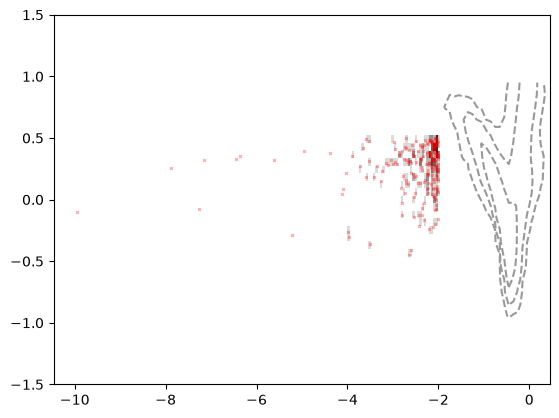

In [8]:
s = (selection['N2'] < -2) & (selection['R3'] < 0.5)
plt.contour(x_centers, y_centers, H, [10, 100, 1000], origin='lower', linestyles='--', colors='0.6')
plt.hist2d(selection[s]['N2'], selection[s]['R3'], bins=(np.linspace(-4, -1.5, 50), np.linspace(-1.5, 1.5, 50)), cmap='gray_r')
plt.plot(selection[s]['N2'], selection[s]['R3'], 'x', color='red', markersize=2, alpha=0.3)

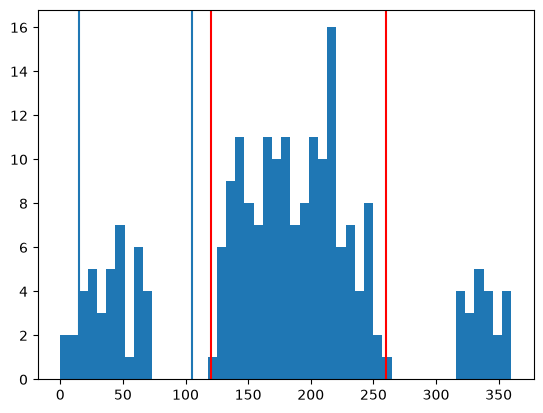

In [9]:
plt.hist(selection[s]['TARGET_RA'], bins=np.linspace(0, 360, 50))
plt.axvline(7 / 24 * 360)
plt.axvline(1 / 24 * 360)
plt.axvline(120, color='red')
plt.axvline(260, color='red')
# plt.axvline(310, color='red')


In [10]:
print(120 / 360 * 24, 260 / 360 * 24, 310 / 360 * 24)

8.0 17.333333333333332 20.666666666666668


To target the bulk in the middle (between the red lines) the run must be some time between Feb 1 and May 10 2027.

This is done assuming +/- 3 hrs of observability from culmination.

In [11]:
sample = selection[s]

In [12]:
sample

,TARGETID,TARGET_RA,TARGET_DEC,Z,HB_N_FLUX,HB_N_FLUX_ERR,OIII5007_FLUX,OIII5007_FLUX_ERR,NII6583_FLUX,NII6583_FLUX_ERR,HA_N_FLUX,HA_N_FLUX_ERR,N2,R3
9719,2389513577955329,44.106653,-0.507696,0.038327,8.934899,0.191784,24.456117,3.282120,0.204023,0.055009,27.025289,0.587046,-2.122091,0.437298
9771,2389515943542784,185.126127,-0.449030,0.006564,206.229731,3.861706,577.477466,8.647430,4.608547,1.161209,571.175291,6.913866,-2.093205,0.447184
11422,2389588811186177,208.383330,2.610605,0.023896,8.522925,0.842572,19.092885,0.101630,0.224327,0.072101,31.772021,0.593314,-2.151164,0.350283
23043,2706274336636928,329.478468,3.435347,0.012136,25.929917,0.354609,33.212266,0.552747,0.704314,0.190042,74.013299,0.893968,-2.021543,0.107497
23147,2706303013093376,242.170484,4.689386,0.040374,60.981173,0.931673,176.828361,2.445836,1.127056,0.191847,199.688451,2.512316,-2.248407,0.462356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3540473,39628016887791925,210.394869,9.517646,0.093188,3.509386,0.636550,6.176051,0.611754,0.078446,0.025983,9.112850,2.149578,-2.065081,0.245480
3585373,39628025758748129,26.543199,9.973341,0.017435,193.914239,2.122980,365.062219,4.659872,50.122014,0.574009,111226.520924,10148.584628,-3.346180,0.274757
3586585,39628027319026473,120.704278,9.980154,0.064763,12.424218,0.010810,19.399840,1.926626,0.336375,0.080952,36.545588,0.565966,-2.036011,0.193529
7347303,39636618214116722,68.977888,1.440603,0.115938,11.231995,0.114512,32.329377,0.812207,0.255484,0.075900,26.686344,0.723877,-2.018926,0.459140


(array([ 0.,  0.,  0., 88., 27., 17., 11.,  8.,  6.,  6., 36.,  0.,  0.,
         0.,  0.,  1.,  0.,  0.,  1.,  1.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20.]),
 <BarContainer object of 20 artists>)

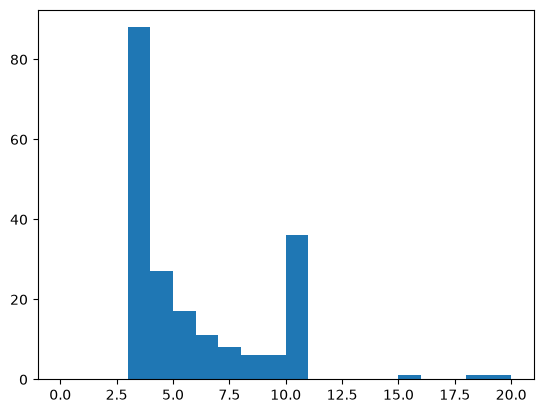

In [13]:
plt.hist(sample["NII6583_FLUX"] / sample["NII6583_FLUX_ERR"], bins=np.linspace(0, 20, 21))